In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
config = {
    # Matrix P
    "sigma_pos": 5.0,
    "sigma_vel": 1.0,
    "sigma_theta": 0.1,
    "sigma_bias_acc": 0.01,
    "sigma_bias_gyro": 0.001,
    
    # Matrix Q
    "drift_pos": 1e-8,
    "drift_vel": 1e-6,
    "drift_theta": 1e-8,
    "drift_bias_acc": 1e-7,
    "drift_bias_gyro": 1e-8,
    
    # Measurements
    "noise_gnss": 2.0,
    "noise_imu": 0.05,
    "noise_gyro": 0.01,
    "noise_compass": 0.001,

    "e_p": 0.1,
    "e_v": 0.5,
    "e_t": 0.1,
    "e_ba": 5e-3,
    "e_bg": 1e-3,
    
    "N_particles" : 25000
}

In [30]:
def generate_ground_truth(T=1000, dt=0.01):
    t = np.arange(0, T, dt)
    v0 = 50.0        # m/s
    ax0 = 0.2         # m/s^2
    A = 100.0        
    omega0 = 0.05     # rad/s

    x = v0*t + 0.5*ax0*t**2
    y = A*np.sin(omega0*t)

    vx = np.gradient(x, dt)
    vy = np.gradient(y, dt)
    ax = np.gradient(vx, dt)
    ay = np.gradient(vy, dt)
    
    theta = np.arctan2(vy, vx)
    omega = np.gradient(theta, dt)

    return t, x, y, vx, vy, ax, ay, theta, omega

t, x, y, vx, vy, ax, ay, theta, omega = generate_ground_truth()

In [31]:
def imu_measurements(t_truth, ax, ay, theta, omega, bias_acc, bias_theta, noise_imu, noise_gyro, rate = 20.0):
    dt = 1 / rate
    t_imu = np.arange(0, t_truth[-1], dt)
    z_imu = np.zeros((len(t_imu), 3))

    for i, ti in enumerate(t_imu) :

        idx = np.searchsorted(t_truth, ti)

        R_w2b = np.array([
            [np.cos(theta[idx]), np.sin(theta[idx])],
            [-np.sin(theta[idx]), np.cos(theta[idx])]
        ])

        a_w = np.array([ax[idx], ay[idx]])
        a_b = R_w2b @ a_w
    
        noise_acc = np.random.randn(2) * noise_imu
        noise_theta = np.random.randn() * noise_gyro
    
        z_imu[i, :2] = a_b + bias_acc + noise_acc
        z_imu[i, 2] = omega[idx] + bias_theta + noise_theta

    return t_imu, z_imu

bias_acc = np.array([0.1, -0.05])
bias_theta = 0.01
t_imu, z_imu = imu_measurements(t, ax, ay, theta,omega, bias_acc, bias_theta, config["noise_imu"], config["noise_gyro"])

In [32]:
def compass_measurements (t_truth, theta, noise_compass, rate = 10) :
    dt = 1 / rate
    t_compass = np.arange(0, t_truth[-1], dt)

    theta_meas = np.interp(t_compass, t_truth, theta)

    noise_theta = np.random.randn(len(t_compass)) * noise_compass

    z_compass = theta_meas + noise_theta

    return t_compass, z_compass

t_compass, z_compass = compass_measurements(t, theta, config["noise_compass"])

In [33]:
def gnss_measurements(t_truth, x, y, noise_gnss, rate = 1.0):
    dt = 1 / rate
    t_gnss = np.arange(0, t_truth[-1], dt)

    x_meas = np.interp(t_gnss, t_truth, x)
    y_meas = np.interp(t_gnss, t_truth, y)

    noise_pos = np.random.randn(len(t_gnss), 2) * noise_gnss

    z_gnss = np.column_stack((x_meas, y_meas)) + noise_pos

    return t_gnss, z_gnss

t_gnss, z_gnss = gnss_measurements(t, x, y, config["noise_gnss"])

In [34]:
def init_kalman(z_gnss, vx0, vy0, theta0, config):
    
    x0 = np.array([z_gnss[0, 0], z_gnss[0, 1], vx0, vy0, theta0, 0, 0, 0]).reshape(-1, 1)
    P0 = np.diag([
        config["sigma_pos"]**2, config["sigma_pos"]**2,
        config["sigma_vel"]**2, config["sigma_vel"]**2,
        config["sigma_theta"]**2,
        config["sigma_bias_acc"], config["sigma_bias_acc"], config["sigma_bias_gyro"]
    ])
    
    H_pos = np.array([
        [1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0]
    ])
    H_ang = np.array([[0, 0, 0, 0, 1, 0, 0, 0]])
    
    R_pos = np.eye(2) * config["noise_gnss"]**2
    R_ang = np.array([[config["noise_compass"]**2]])

    return x0, P0, H_pos, H_ang, R_pos, R_ang

In [35]:
def run_kalman_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu,  z_compass, x_hat, P, H_pos, H_ang, R_pos, R_ang, config) :

    dt = t_imu[1] - t_imu[0]
    x_estimates = []

    gnss_idx = 0
    compass_idx = 0

    for k in range(len(t_imu)):

        ax_m, ay_m, om_m = z_imu[k]
        bax, bay, bg = x_hat[5,0], x_hat[6,0], x_hat[7,0]
        theta = x_hat[4,0]
        
        ax_b, ay_b, om_b = ax_m - bax, ay_m - bay, om_m - bg
        c, s = np.cos(theta), np.sin(theta)
        ax_w = ax_b * c - ay_b * s
        ay_w = ax_b * s + ay_b * c
        
        F = np.eye(8)
        F[0,2] = F[1,3] = dt
        F[0,4] = 0.5*dt**2 * (-ax_b*s - ay_b*c)
        F[1,4] = 0.5*dt**2 * ( ax_b*c - ay_b*s)
        F[2,4] = dt * (-ax_b*s - ay_b*c)
        F[3,4] = dt * ( ax_b*c - ay_b*s)
        F[2,5], F[2,6] = -c*dt,  s*dt
        F[3,5], F[3,6] = -s*dt, -c*dt
        F[4,7] = -dt
        
        Q = np.zeros((8,8))
        Q[0:4, 0:4] = np.eye(4) * (config["noise_imu"]**2 * dt)
        Q[4,4] = config["noise_gyro"]**2 * dt
        Q[5,5] = Q[6,6] = config["drift_bias_acc"] * dt
        Q[7,7] = config["drift_bias_gyro"] * dt

        x_hat[0,0] += x_hat[2,0]*dt + 0.5*ax_w*dt**2
        x_hat[1,0] += x_hat[3,0]*dt + 0.5*ay_w*dt**2
        x_hat[2,0] += ax_w*dt
        x_hat[3,0] += ay_w*dt
        x_hat[4,0] += om_b*dt
        x_hat[4,0] = np.arctan2(np.sin(x_hat[4,0]), np.cos(x_hat[4,0]))
        
        P = F @ P @ F.T + Q

        if compass_idx < len(t_compass) and t_imu[k] >= t_compass[compass_idx]:
            z_c = z_compass[compass_idx]
            y_c = z_c - H_ang @ x_hat
            S_c = H_ang @ P @ H_ang.T + R_ang
            K_c = P @ H_ang.T @ np.linalg.inv(S_c)

            x_hat = x_hat + K_c @ y_c
            P = (np.eye(8) - K_c @ H_ang) @ P @ (np.eye(8) - K_c @ H_ang).T + K_c @ R_ang @ K_c.T
            compass_idx += 1
        
        if gnss_idx < len(t_gnss) and t_imu[k] >= t_gnss[gnss_idx]:
            z = z_gnss[gnss_idx].reshape(2,1)

            if not np.isnan(z).any():
                z = z.reshape(-1, 1)
                y = z - H_pos @ x_hat
                S = H_pos @ P @ H_pos.T + R_pos
                K = P @ H_pos.T @ np.linalg.inv(S)
                
                x_hat = x_hat + K @ y
                P = (np.eye(8) - K @ H_pos) @ P @ (np.eye(8) - K @ H_pos).T + K @ R_pos @ K.T
                
            gnss_idx += 1

        x_estimates.append(x_hat.copy())
    return np.array(x_estimates)

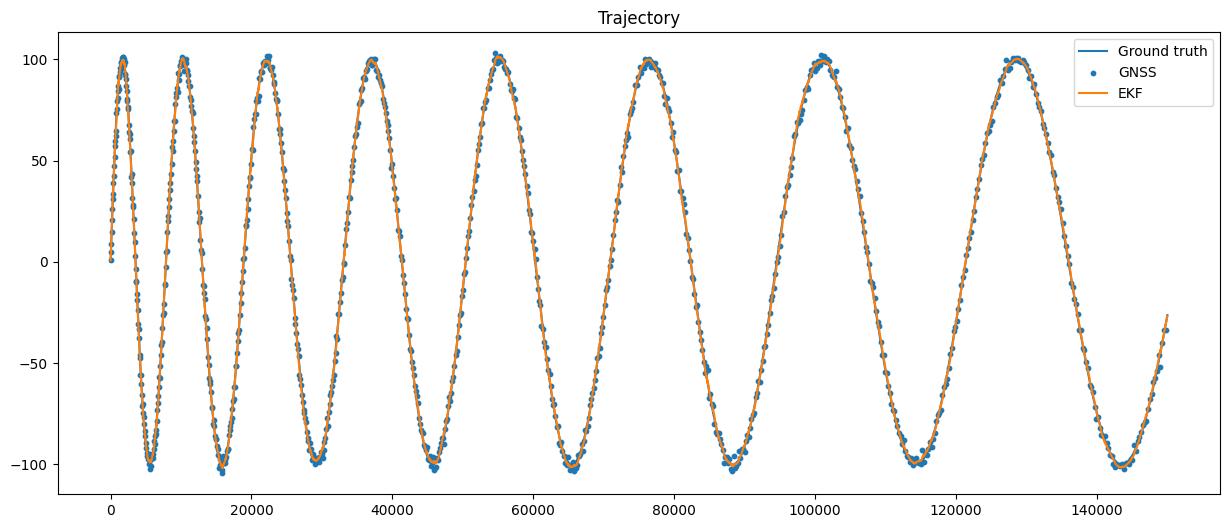

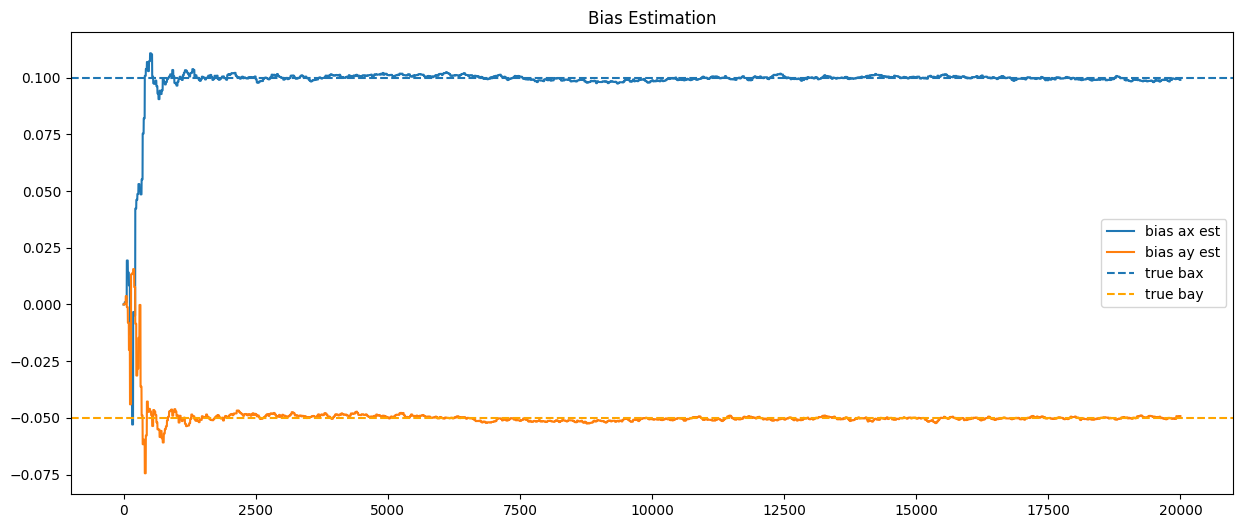

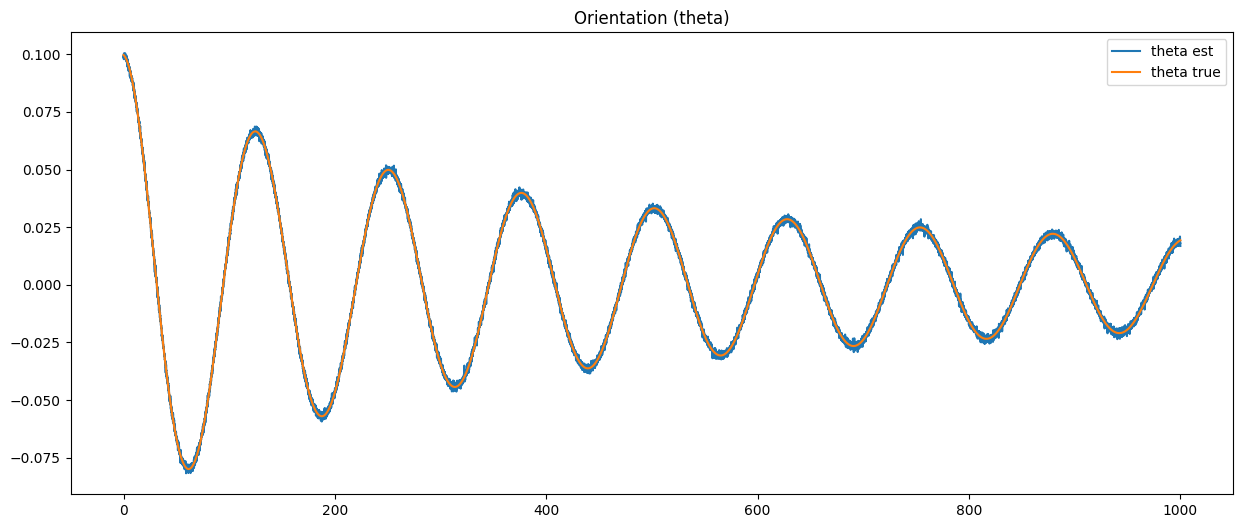

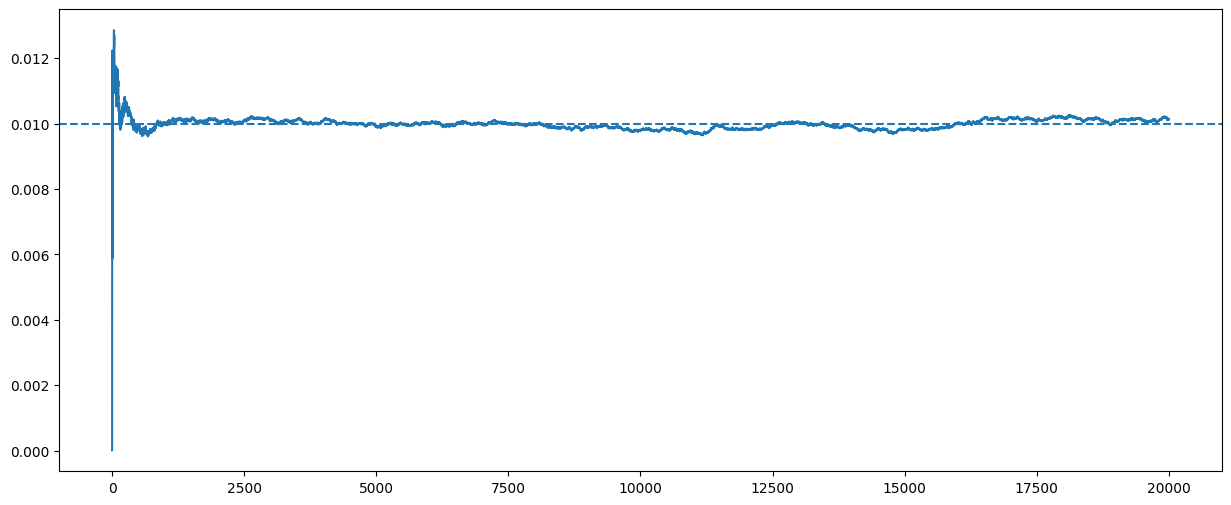

In [36]:
x0, P0, H_pos, H_ang, R_pos, R_ang = init_kalman(z_gnss, vx[0], vy[0], theta[0], config)
x_kalman = run_kalman_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu, z_compass, x0, P0, H_pos, H_ang, R_pos, R_ang, config).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_gnss[:,0], z_gnss[:,1], s= 10, label = "GNSS")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "EKF")
plt.legend()
plt.title("Trajectory")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_kalman[:,5], label="bias ax est")
plt.plot(x_kalman[:,6], label="bias ay est")
plt.axhline(0.1, linestyle="--", label="true bax")
plt.axhline(-0.05, linestyle="--", color ="orange", label="true bay")
plt.legend()
plt.title("Bias Estimation")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(t_imu, x_kalman[:, 4], label="theta est")
plt.plot(t, theta, label="theta true")
plt.legend()
plt.title("Orientation (theta)")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_kalman[:,7])
plt.axhline(0.01, linestyle="--")

In [37]:
def init_particles(z_gnss, vx0, vy0, theta0, config):
    
    N = config["N_particles"]
    
    sigma_pos = config["sigma_pos"]
    sigma_vel = config["sigma_vel"]
    sigma_theta = config["sigma_theta"]
    sigma_bias_acc = config["sigma_bias_acc"]
    sigma_bias_gyro = config["sigma_bias_gyro"]
    
    particles = np.zeros((N, 8))
    
    particles[:, 0] = z_gnss[0, 0] + np.random.randn(N) * sigma_pos
    particles[:, 1] = z_gnss[0, 1] + np.random.randn(N) * sigma_pos
    particles[:, 2] = vx0 + np.random.randn(N) * sigma_vel
    particles[:, 3] = vy0 + np.random.randn(N) * sigma_vel
    particles[:, 4] = z_compass[0] + np.random.uniform(-np.pi, np.pi, N) * sigma_theta
    particles[:, 5:7] = np.random.randn(N, 2) * sigma_bias_acc
    particles[:, 7] = np.random.randn(N) * sigma_bias_gyro
    
    weights = np.ones(N) / N

    return particles, weights

In [38]:
def predict_particles(particles, z_imu, dt, config) :
    N = particles.shape[0]

    ax_meas = z_imu[0]
    ay_meas = z_imu[1]
    omega_meas = z_imu[2]
    
    bax, bay, b_gyro = particles[:, 5], particles[:, 6], particles[:, 7]
    ax_b = ax_meas - bax
    ay_b = ay_meas - bay
    omega = omega_meas - b_gyro

    c = np.cos(particles[:, 4])
    s = np.sin(particles[:, 4])

    ax_w = ax_b*c - ay_b*s
    ay_w = ax_b*s + ay_b*c
        
    noise_pos = np.random.randn(N, 2) * config["e_p"] 
    noise_vel = np.random.randn(N, 2) * config["e_v"] 
    noise_theta = np.random.randn(N) * config["e_t"] 
    noise_bias_acc = np.random.randn(N, 2) * config["e_ba"] 
    noise_bias_gyro = np.random.randn(N) * config["e_bg"] 
    
    particles[:, 0] += particles[:, 2] * dt + 0.5 * ax_w * dt**2 + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + 0.5 * ay_w * dt**2 + noise_pos[:, 1]
    particles[:, 2] += ax_w * dt + noise_vel[:, 0]
    particles[:, 3] += ay_w * dt + noise_vel[:, 1]
    particles[:, 4] += omega * dt + noise_theta
    particles[:, 5] += noise_bias_acc[:, 0]
    particles[:, 6] += noise_bias_acc[:, 1]
    particles[:, 7] += noise_bias_gyro

    particles[:, 4] = np.arctan2(np.sin(particles[:, 4]), np.cos(particles[:, 4]))
    
    return particles

In [39]:
def update_weights_position(particles, weights, z_gnss, config) :
    x_pos = z_gnss[0]
    y_pos = z_gnss[1]
    
    dx = particles[:, 0] - x_pos
    dy = particles[:, 1] - y_pos
    d2_pos = dx**2 + dy**2

    log_w = -0.5 * (d2_pos / config["noise_gnss"]**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [40]:
def update_weights_angle(particles, weights, z_compass, config) :
    theta = z_compass
    
    dtheta = particles[:, 4] - theta
    d2_ang = dtheta**2

    log_w = -0.5 * (d2_ang / config["noise_compass"]**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [41]:
def N_eff(weights) :
    return 1. / np.sum(weights**2)

In [42]:
def resample(particles, weights) :
    N = len(weights)
    positions = (np.arange(N) + np.random.rand()) / N

    indexes = np.zeros(N, dtype = int)
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0

    while i < N :
        if positions[i] < cumulative_sum[j] :
            indexes[i] = j
            i += 1  
        else :
            j += 1

    particles[:] = particles[indexes]
    weights.fill(1 / N)

    return particles, weights

In [43]:
def run_particle_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu, z_compass, particles, weights, config):
    estimates = []
    x_est0 = np.average(particles, weights=weights, axis=0)
    estimates.append(x_est0.copy())

    gnss_idx = 0
    compass_idx = 0
    
    for k in range(1, len(t_imu)):
        dt = t_imu[k] - t_imu[k-1]
        
        gnss_presente = gnss_idx < len(t_gnss) and t_imu[k] >= t_gnss[gnss_idx]
        
        gnss_valid = False
        if gnss_presente:

            if not np.isnan(z_gnss[gnss_idx][0]): 
                gnss_valid = True

        current_config = config.copy()
        if not gnss_valid:
            current_config["e_p"] = 0.0
            current_config["e_v"] = 0.0 
            current_config["e_ba"] = 0.0
            current_config["e_bg"] = 0.0

        particles = predict_particles(particles, z_imu[k], dt, current_config)

        if gnss_presente:
            if gnss_valid:
                weights = update_weights_position(particles, weights, z_gnss[gnss_idx], config)
                
                if N_eff(weights) < config["N_particles"] * 0.7:
                    particles, weights = resample(particles, weights)
            
            gnss_idx += 1

        if compass_idx < len(t_compass) and t_imu[k] >= t_compass[compass_idx]:
            weights = update_weights_angle(particles, weights, z_compass[compass_idx], config)
            compass_idx += 1
    
        x_hat = np.average(particles, weights=weights, axis=0)
        estimates.append(x_hat.copy())
        
    return np.array(estimates)

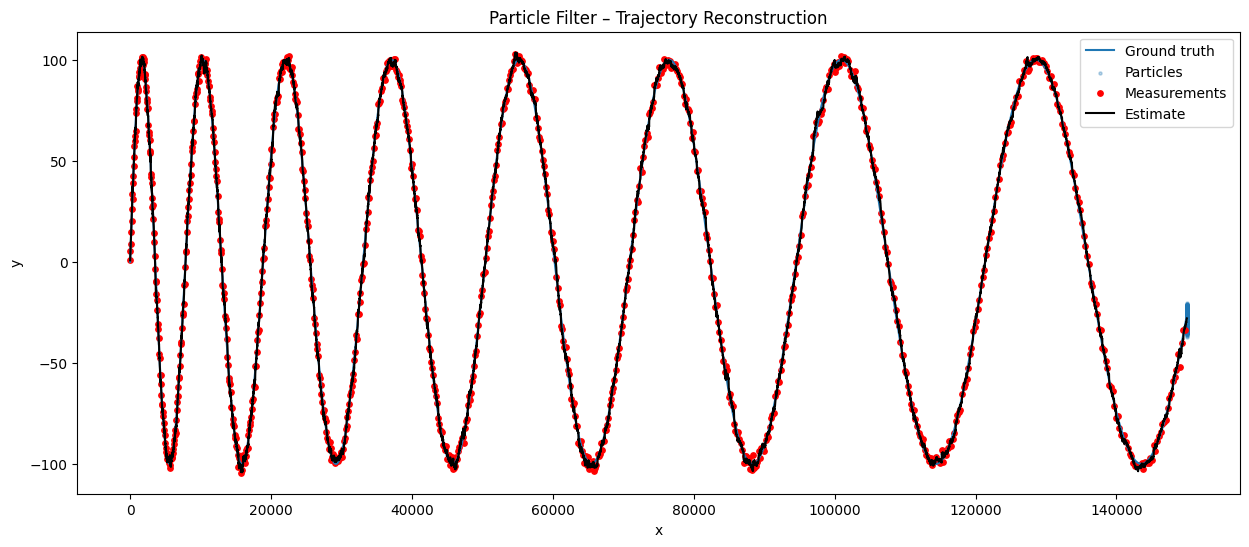

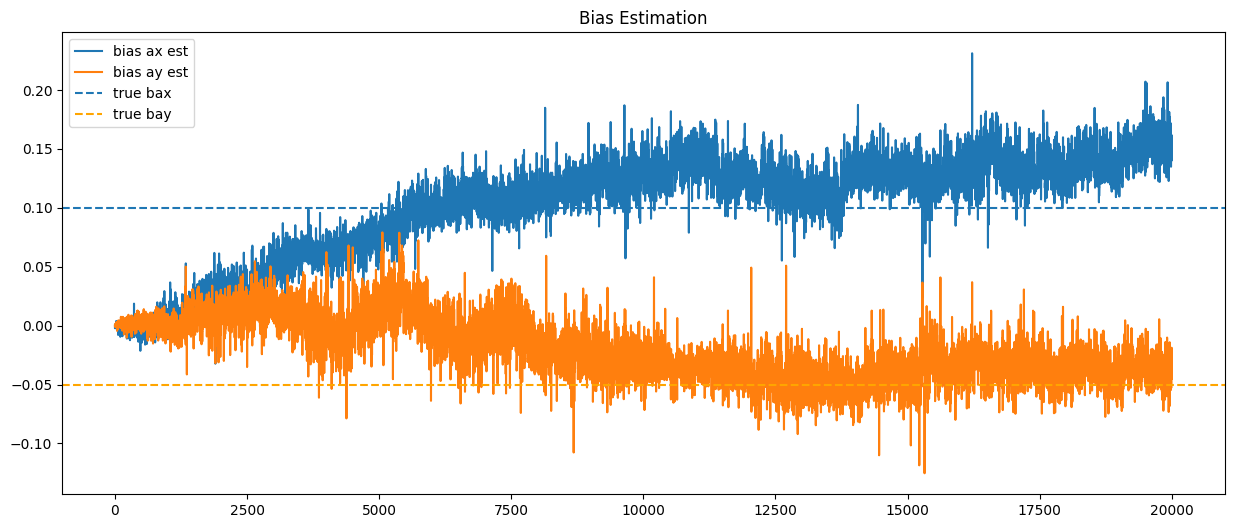

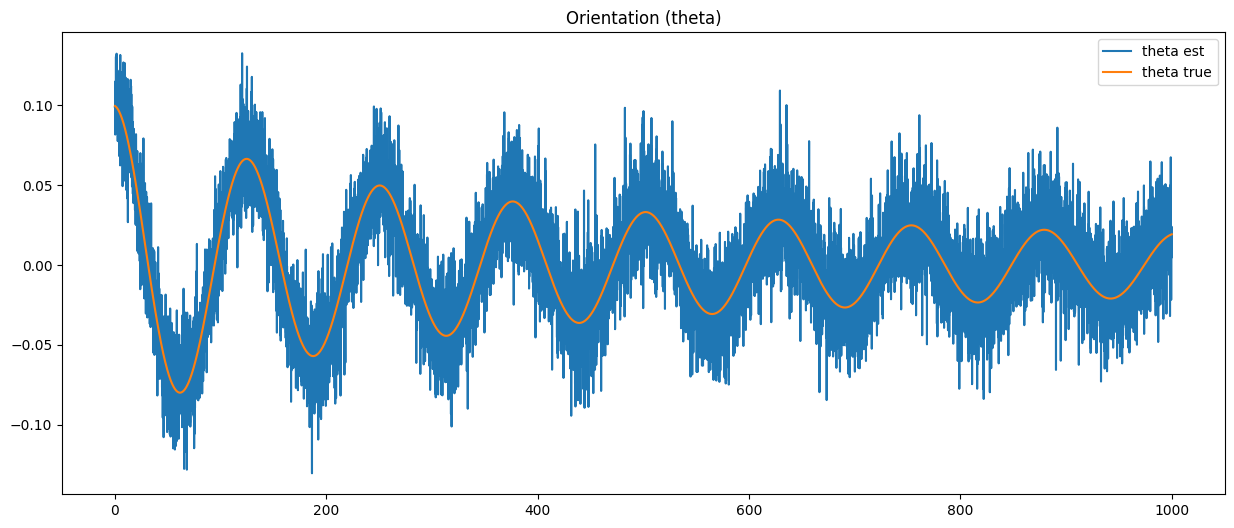

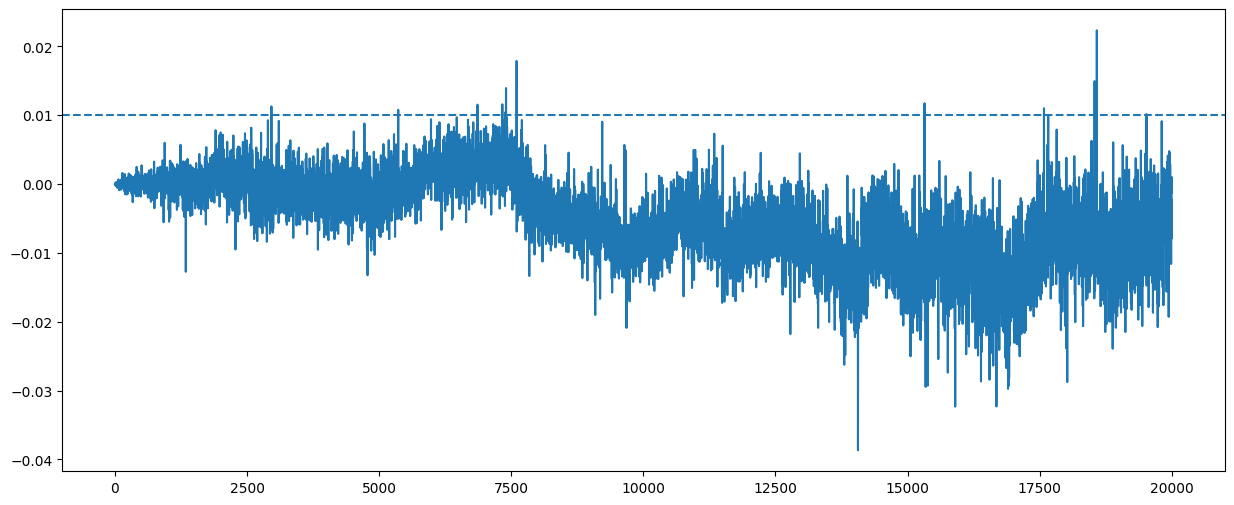

In [44]:
particles, weights = init_particles(z_gnss, vx[0], vy[0], theta[0], config)
x_pf = run_particle_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu, z_compass, particles, weights, config)

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_gnss[:, 0], z_gnss[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_pf[:,5], label="bias ax est")
plt.plot(x_pf[:,6], label="bias ay est")
plt.axhline(0.1, linestyle="--", label="true bax")
plt.axhline(-0.05, linestyle="--", color ="orange", label="true bay")
plt.legend()
plt.title("Bias Estimation")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(t_imu, x_pf[:, 4], label="theta est")
plt.plot(t, theta, label="theta true")
plt.legend()
plt.title("Orientation (theta)")
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(x_pf[:,7])
plt.axhline(0.01, linestyle="--")

In [45]:
def rms_position(x_est, x_true) :
    error_pos = x_est[:, :2] - x_true[:, :2]
    return np.sqrt(np.mean(np.sum(error_pos**2, axis = 1)))

In [46]:
def rms_velocity(x_est, x_true) :
    error_vel = x_est[:, 2:4] - x_true[:, 2:4]
    return np.sqrt(np.mean(np.sum(error_vel**2, axis = 1)))

In [47]:
def rms_angle(x_est, x_true) :
    error_angle = x_est[:, 4] - x_true[:, 4]
    return np.sqrt(np.mean(np.sum(error_angle**2)))

In [48]:
x_true = np.column_stack((
    np.interp(t_imu, t, x),
    np.interp(t_imu, t, y),
    np.interp(t_imu, t, vx),
    np.interp(t_imu, t, vy),
    np.interp(t_imu, t, theta)
))

In [49]:
rms_kalman_pos = rms_position(x_kalman, x_true)
rms_pf_pos = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_pos)
print("RMS Particle Filter: ", rms_pf_pos)

RMS Kalman:  1.2841630046789987
RMS Particle Filter:  2.276344819417361


In [50]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  0.14648388581615718
RMS Particle Filter:  0.7224255548333288


In [51]:
rms_kalman_ang = rms_angle(x_kalman, x_true)
rms_pf_ang = rms_angle(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_ang)
print("RMS Particle Filter: ", rms_pf_ang)

RMS Kalman:  0.13970582533239112
RMS Particle Filter:  2.027994330647747


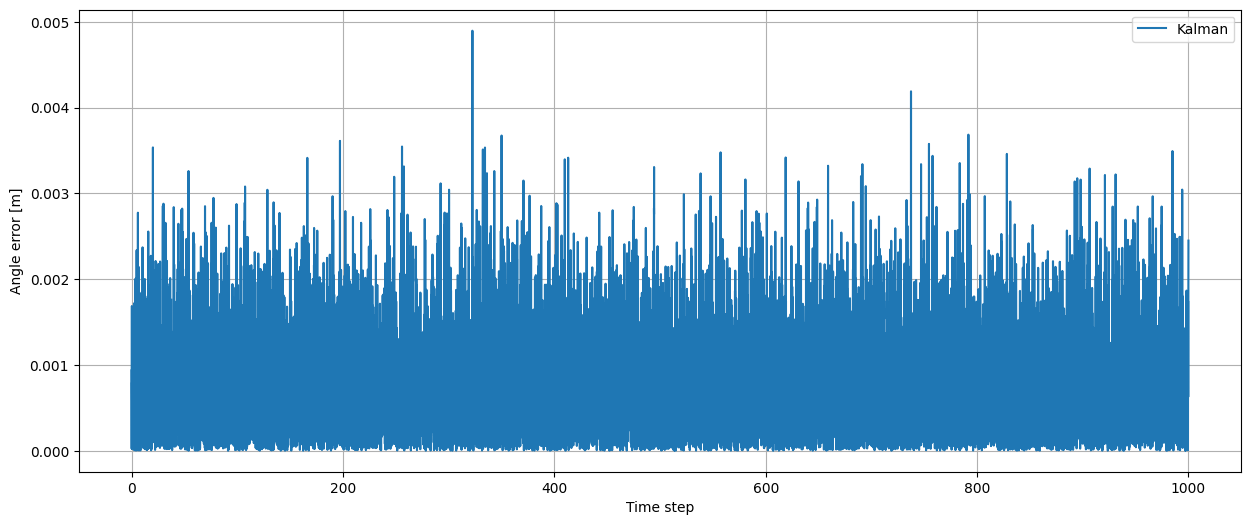

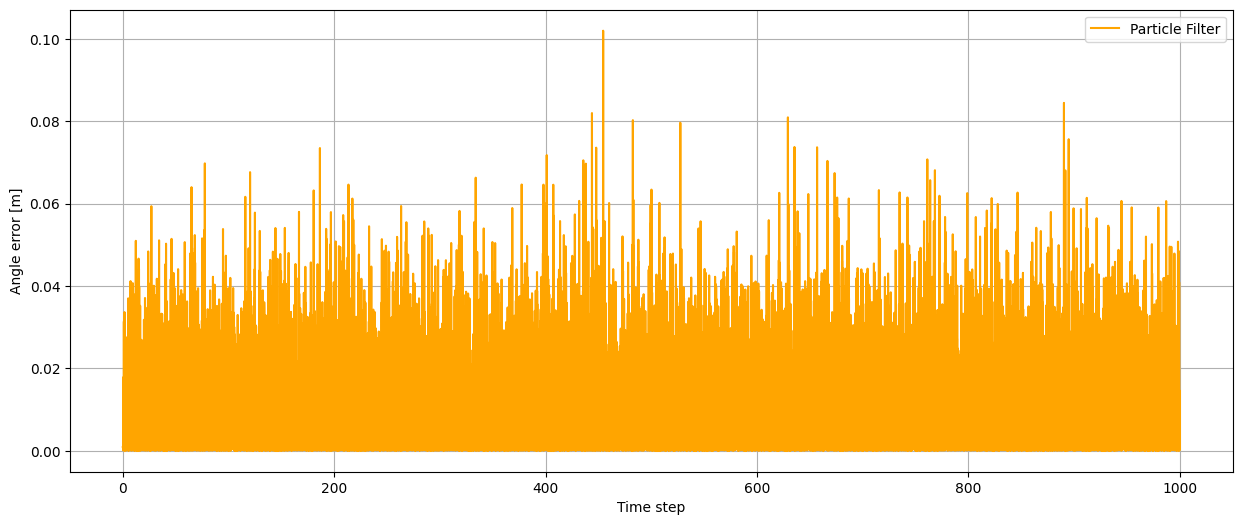

In [52]:
error_kalman = np.abs(x_kalman[:, 4] - x_true[:, 4])
error_pf = np.abs(x_pf[:, 4] - x_true[:, 4])

plt.figure(figsize = (15, 6))
plt.plot(t_imu, error_kalman, label = "Kalman")
plt.xlabel("Time step")
plt.ylabel("Angle error [m]")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize = (15, 6))
plt.plot(t_imu, error_pf, color= "orange", label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Angle error [m]")
plt.legend()
plt.grid()
plt.show()

In [53]:
def simulate_sensor_outage(t_sensor, z_sensor, outages):
    
    z_corrupted = z_sensor.copy().astype(float)
    
    for t_start, t_end in outages:
        
        mask = (t_sensor >= t_start) & (t_sensor <= t_end)
        z_corrupted[mask] = np.nan
        
    return z_corrupted

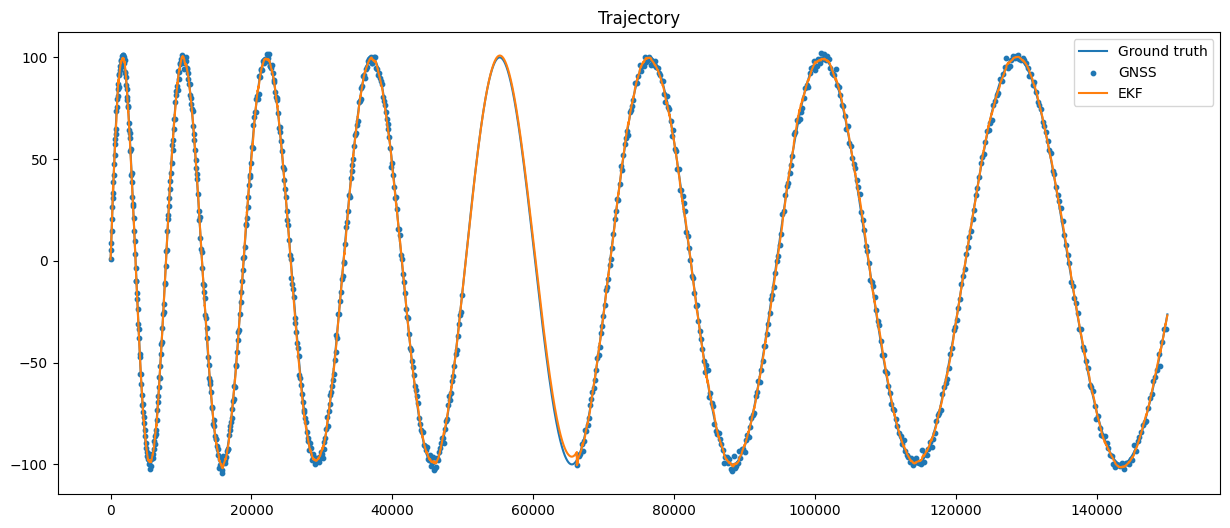

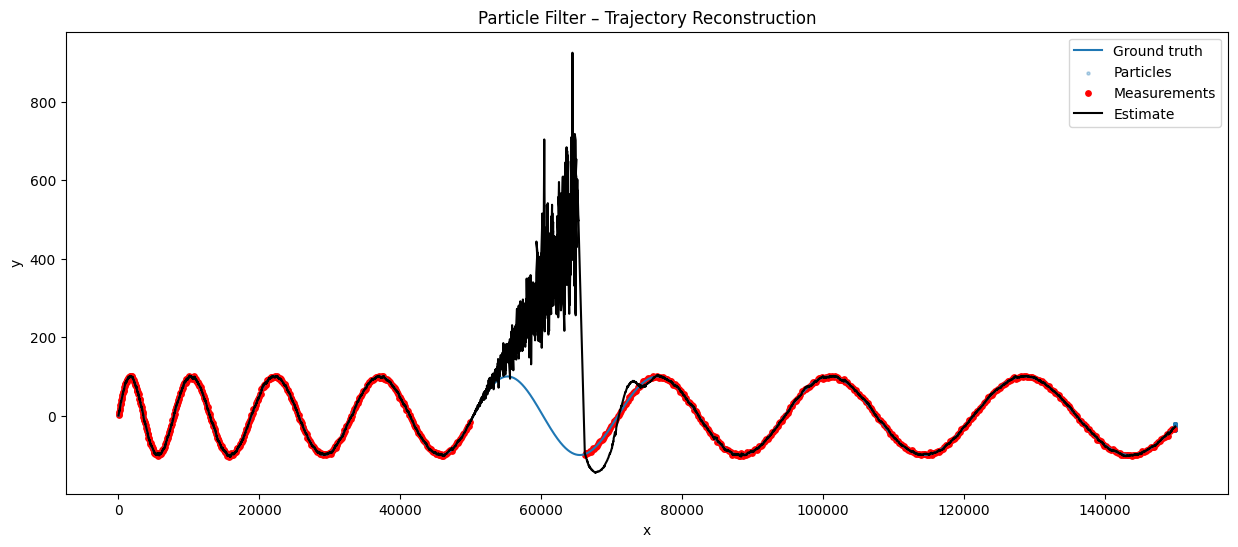

In [54]:
outages = [(500, 600)] 
z_gnss = simulate_sensor_outage(t_gnss, z_gnss, outages)

x0, P0, H_pos, H_ang, R_pos, R_ang = init_kalman(z_gnss, vx[0], vy[0], theta[0], config)
x_kalman = run_kalman_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu, z_compass, x0, P0, H_pos, H_ang, R_pos, R_ang, config).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_gnss[:,0], z_gnss[:,1], s= 10, label = "GNSS")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "EKF")
plt.legend()
plt.title("Trajectory")
plt.show()

particles, weights = init_particles(z_gnss, vx[0], vy[0], theta[0], config)
x_pf = run_particle_filter(t_gnss, t_imu, t_compass, z_gnss, z_imu, z_compass, particles, weights, config)

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_gnss[:, 0], z_gnss[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()